# <p style="text-align: center;">Lost In The Mountains</p>
##### <p style="text-align: center;"> Milestone 1</p>
https://github.com/jonmoses/Lost-In-The-Mountains/tree/main

| Jonathan Moses    | Brooklyn Epperson | Audrey Burrows        |
|:------------------|:-----------------:|----------------------:|
| u1163027          |     u1467539      | u1410064              |
| u1163027@utah.edu | u1467539@utah.edu | u1410064@umail.utah.edu |

## Background and Motivation

## Data Description


Our analysis draws on four datasets and one official classification reference:

---

### 1. NamUs Missing Persons — Geocoded (`missing_persons_with_coords.csv`)
**Source:** National Missing and Unidentified Persons System (NamUs), U.S. Department of Justice  
**Records:** 6,145 cases | **Coverage:** 13 Appalachian states (AL, GA, KY, MD, MS, NC, NY, OH, PA, SC, TN, VA, WV) | **Date range:** 1948–2023

This is the primary dataset. It was downloaded directly from NamUs and filtered to the Appalachian region, then enriched with latitude/longitude coordinates via geocoding (county centroid lookup) to enable spatial analysis. Each row represents one open missing persons case and includes:

| Column | Description |
|---|---|
| `Case Number` | Unique NamUs case ID |
| `DLC` | Date of last contact (MM/DD/YYYY) |
| `Missing Age` | Age at time of disappearance |
| `City / County / State` | Last known location |
| `Biological Sex` | Male / Female |
| `Race / Ethnicity` | Self-reported racial/ethnic identity |
| `lat` / `lng` | Geocoded coordinates (county centroid) |

Names have been dropped from our working copy to protect individual identities.

**Demographics snapshot:** ~58% male, ~42% female; White/Caucasian (~58%), Black/African American (~26%), Hispanic/Latino (~8%).

---

### 2. NamUs Raw Download (`download_02-13-2026.21_02_57.csv`)
**Source:** NamUs.gov  
**Records:** 6,002 cases | Same 11-column schema as above, without geocoded coordinates.

This is the unmodified export used as the source for dataset 1.

---

### 3. U.S. Counties Reference (`uscounties.csv`)
**Source:** Public county-level geographic dataset  
**Records:** 3,144 U.S. counties

Used as a lookup table during geocoding and for joining county-level contextual data. Key fields: `county`, `state_id`, `county_fips`, `lat`, `lng`, `population`. The `population` field is used to normalize missing persons counts to a per-100,000-residents rate for fair cross-county comparison.

---

### 4. Bear Attacks (`bear_attacks.csv`)
**Source:** Compiled bear attack incident records  
**Records:** 166 incidents (120 with valid coordinates)

Contains historical bear attack records with fields including victim age, gender, date, location (free text + lat/lng), bear species, and incident type. Used as an environmental hazard layer in the geospatial analysis. We've discovered its a little too small to use in the way we originally planned.



## Preliminary Results

Appalachian Proper (ARC) :  421 counties | mean: 7.30 | median: 5.29 cases per 100k
Non-Appalachian          :  677 counties | mean: 6.88 | median: 3.93 cases per 100k


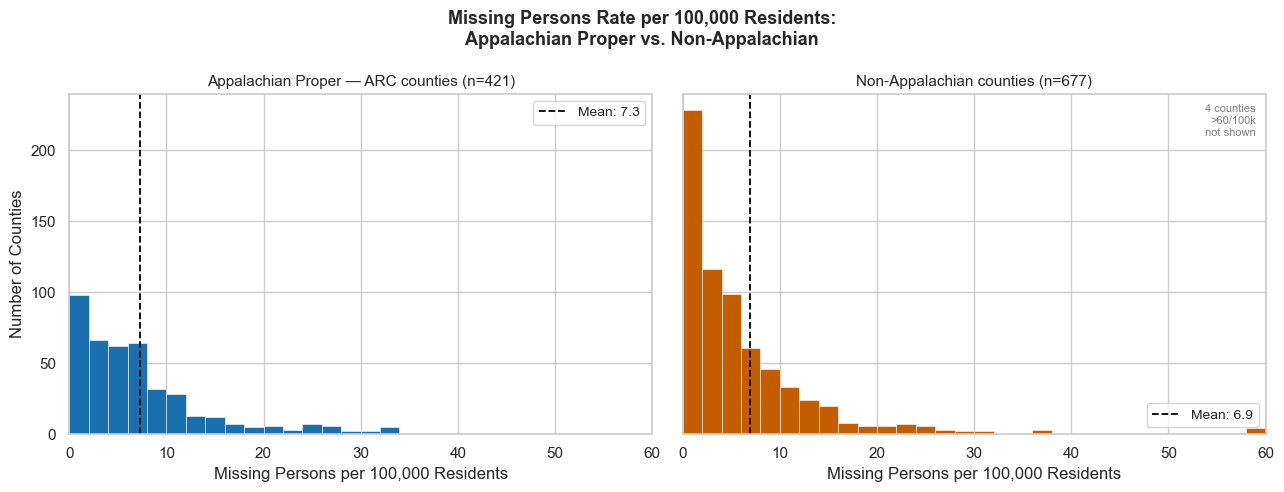

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Official Appalachian county list (taken from arc.gov)
arc_counties = {
    "AL": ["Bibb","Blount","Calhoun","Chambers","Cherokee","Chilton","Clay","Cleburne",
           "Colbert","Coosa","Cullman","De Kalb","Elmore","Etowah","Fayette","Franklin",
           "Hale","Jackson","Jefferson","Lamar","Lauderdale","Lawrence","Limestone","Macon",
           "Madison","Marion","Marshall","Morgan","Pickens","Randolph","St. Clair","Shelby",
           "Talladega","Tallapoosa","Tuscaloosa","Walker","Winston"],
    "GA": ["Banks","Barrow","Bartow","Carroll","Catoosa","Chattooga","Cherokee","Dade",
           "Dawson","Douglas","Elbert","Fannin","Floyd","Forsyth","Franklin","Gilmer",
           "Gordon","Gwinnett","Habersham","Hall","Haralson","Hart","Heard","Jackson",
           "Lumpkin","Madison","Murray","Paulding","Pickens","Polk","Rabun","Stephens",
           "Towns","Union","Walker","White","Whitfield"],
    "KY": ["Adair","Bath","Bell","Boyd","Breathitt","Carter","Casey","Clark","Clay",
           "Clinton","Cumberland","Edmonson","Elliott","Estill","Fleming","Floyd","Garrard",
           "Green","Greenup","Harlan","Hart","Jackson","Johnson","Knott","Knox","Laurel",
           "Lawrence","Lee","Leslie","Letcher","Lewis","Lincoln","McCreary","Madison",
           "Magoffin","Martin","Menifee","Metcalfe","Monroe","Montgomery","Morgan","Nicholas",
           "Owsley","Perry","Pike","Powell","Pulaski","Robertson","Rockcastle","Rowan",
           "Russell","Wayne","Whitley","Wolfe"],
    "MD": ["Allegany","Garrett","Washington"],
    "MS": ["Alcorn","Benton","Calhoun","Chickasaw","Choctaw","Clay","Itawamba","Kemper",
           "Lee","Lowndes","Marshall","Monroe","Montgomery","Noxubee","Oktibbeha","Panola",
           "Pontotoc","Prentiss","Tippah","Tishomingo","Union","Webster","Winston","Yalobusha"],
    "NY": ["Allegany","Broome","Cattaraugus","Chautauqua","Chemung","Chenango","Cortland",
           "Delaware","Otsego","Schoharie","Schuyler","Steuben","Tioga","Tompkins"],
    "NC": ["Alexander","Alleghany","Ashe","Avery","Buncombe","Burke","Caldwell","Catawba",
           "Cherokee","Clay","Cleveland","Davie","Forsyth","Graham","Haywood","Henderson",
           "Jackson","McDowell","Macon","Madison","Mitchell","Polk","Rutherford","Stokes",
           "Surry","Swain","Transylvania","Watauga","Wilkes","Yadkin","Yancey"],
    "OH": ["Adams","Ashtabula","Athens","Belmont","Brown","Carroll","Clermont","Columbiana",
           "Coshocton","Gallia","Guernsey","Harrison","Highland","Hocking","Holmes","Jackson",
           "Jefferson","Lawrence","Mahoning","Meigs","Monroe","Morgan","Muskingum","Noble",
           "Perry","Pike","Ross","Scioto","Trumbull","Tuscarawas","Vinton","Washington"],
    "PA": ["Allegheny","Armstrong","Beaver","Bedford","Blair","Bradford","Butler","Cambria",
           "Cameron","Carbon","Centre","Clarion","Clearfield","Clinton","Columbia","Crawford",
           "Elk","Erie","Fayette","Forest","Fulton","Greene","Huntingdon","Indiana","Jefferson",
           "Juniata","Lackawanna","Lawrence","Luzerne","Lycoming","McKean","Mercer","Mifflin",
           "Monroe","Montour","Northumberland","Perry","Pike","Potter","Schuylkill","Snyder",
           "Somerset","Sullivan","Susquehanna","Tioga","Union","Venango","Warren","Washington",
           "Wayne","Westmoreland","Wyoming"],
    "SC": ["Anderson","Cherokee","Greenville","Oconee","Pickens","Spartanburg","Union"],
    "TN": ["Anderson","Bledsoe","Blount","Bradley","Campbell","Cannon","Carter","Claiborne",
           "Clay","Cocke","Coffee","Cumberland","De Kalb","Fentress","Franklin","Grainger",
           "Greene","Grundy","Hamblen","Hamilton","Hancock","Hawkins","Jackson","Jefferson",
           "Johnson","Knox","Lawrence","Lewis","Loudon","McMinn","Macon","Marion","Meigs",
           "Monroe","Morgan","Overton","Pickett","Polk","Putnam","Rhea","Roane","Scott",
           "Sequatchie","Sevier","Smith","Sullivan","Unicoi","Union","Van Buren","Warren",
           "Washington","White"],
    "VA": ["Alleghany","Bath","Bland","Botetourt","Buchanan","Carroll","Craig","Dickenson",
           "Floyd","Giles","Grayson","Henry","Highland","Lee","Montgomery","Patrick","Pulaski",
           "Rockbridge","Russell","Scott","Smyth","Tazewell","Washington","Wise","Wythe"],
    "WV": ["Barbour","Berkeley","Boone","Braxton","Brooke","Cabell","Calhoun","Clay",
           "Doddridge","Fayette","Gilmer","Grant","Greenbrier","Hampshire","Hancock","Hardy",
           "Harrison","Jackson","Jefferson","Kanawha","Lewis","Lincoln","Logan","Marion",
           "Marshall","Mason","McDowell","Mercer","Mineral","Mingo","Monongalia","Monroe",
           "Morgan","Nicholas","Ohio","Pendleton","Pleasants","Pocahontas","Preston","Putnam",
           "Raleigh","Randolph","Ritchie","Roane","Summers","Taylor","Tucker","Tyler","Upshur",
           "Wayne","Webster","Wetzel","Wirt","Wood","Wyoming"],
}

arc_set = {
    (county.lower(), state)
    for state, counties in arc_counties.items()
    for county in counties
}

# Load data and classify into type of county
df_mp  = pd.read_csv("data/missing_persons_with_coords.csv")
df_ref = pd.read_csv("data/uscounties.csv")

df_ref = df_ref[df_ref["state_id"].isin(arc_counties.keys())].copy()
df_ref["in_arc"] = df_ref.apply(
    lambda r: (r["county_ascii"].lower(), r["state_id"]) in arc_set, axis=1
)

df_mp["County_clean"] = df_mp["County"].str.strip()
mp_counts = (
    df_mp.groupby(["County_clean", "State"])
    .size()
    .reset_index(name="mp_count")
    .rename(columns={"County_clean": "county_ascii", "State": "state_id"})
)

merged = df_ref.merge(mp_counts, on=["county_ascii", "state_id"], how="left")
merged["mp_count"] = merged["mp_count"].fillna(0)

# scale the missing persons cases by population of county
merged["mp_per_100k"] = (merged["mp_count"] / merged["population"]) * 100_000
merged = merged[merged["population"] > 0]   # drop any zero-pop rows

app = merged.loc[merged["in_arc"],  "mp_per_100k"]
non = merged.loc[~merged["in_arc"], "mp_per_100k"]

print(f"Appalachian Proper (ARC) : {len(app):>4} counties | mean: {app.mean():.2f} | median: {app.median():.2f} cases per 100k")
print(f"Non-Appalachian          : {len(non):>4} counties | mean: {non.mean():.2f} | median: {non.median():.2f} cases per 100k")

# make the graphs
# there are some huge outliers in the dataset, so i'm setting the max missing people per 100,000 to 60 to make the graphs more readable
CAP = 60
bins = np.arange(0, CAP + 2, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    "Missing Persons Rate per 100,000 Residents:\nAppalachian Proper vs. Non-Appalachian",
    fontsize=13, fontweight="bold"
)

ax1.hist(app.clip(upper=CAP), bins=bins, color="#1a6faf", edgecolor="white", linewidth=0.4)
ax1.axvline(app.mean(), color="black", linestyle="--", linewidth=1.3, label=f"Mean: {app.mean():.1f}")
ax1.set_title(f"Appalachian Proper — ARC counties (n={len(app)})", fontsize=11)
ax1.set_xlabel("Missing Persons per 100,000 Residents")
ax1.set_ylabel("Number of Counties")
ax1.set_xlim(0, CAP)
ax1.legend(fontsize=10)

ax2.hist(non.clip(upper=CAP), bins=bins, color="#c45c00", edgecolor="white", linewidth=0.4)
ax2.axvline(non.mean(), color="black", linestyle="--", linewidth=1.3, label=f"Mean: {non.mean():.1f}")
ax2.set_title(f"Non-Appalachian counties (n={len(non)})", fontsize=11)
ax2.set_xlabel("Missing Persons per 100,000 Residents")
ax2.set_xlim(0, CAP)
ax2.legend(fontsize=10)

for ax, series, label in [(ax1, app, "ARC"), (ax2, non, "non-ARC")]:
    n_clipped = int((series > CAP).sum())
    if n_clipped:
        ax.text(CAP - 1, ax.get_ylim()[1] * 0.97,
                f"{n_clipped} counties\n>{CAP}/100k\nnot shown",
                ha="right", va="top", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/missing_persons_with_coords.csv")

# Format the date with pandas to_datetime method, data is in m/d/y in the csv from NamUs.
df["DLC"] = pd.to_datetime(df["DLC"], format="%m/%d/%Y")
df["Year"] = df["DLC"].dt.year
df["Month"] = df["DLC"].dt.month
df["Age"] = pd.to_numeric(df["Missing Age"].str.replace(" Years", "", regex=False), errors="coerce")


# Race has multiple entries sometimes if a person is mixed so im just combining them into a new multiracial
# Category for now. We should probably change this later on in the project and handle it more carefully.
df["Race"] = df["Race / Ethnicity"].apply(lambda x: "Multiracial" if "," in str(x) else x)


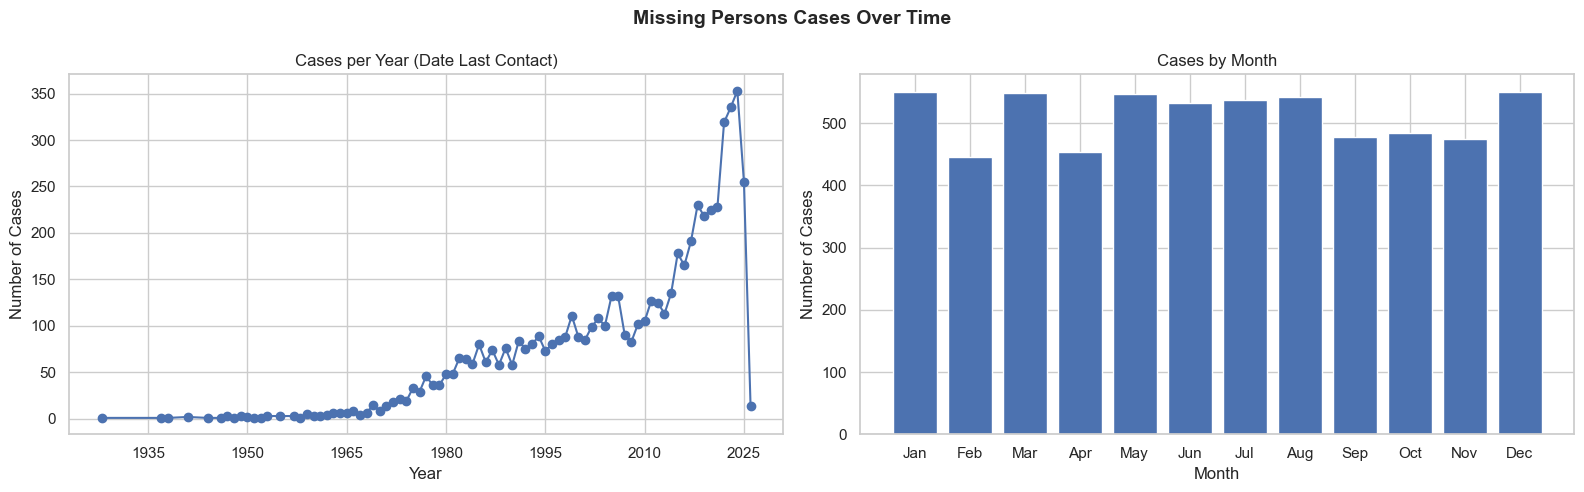

In [32]:
# Plotting cases over time

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Missing Persons Cases Over Time", fontsize=14, fontweight="bold")

year_counts = df.groupby("Year").size()

axes[0].plot(year_counts.index, year_counts.values, marker="o")
axes[0].set_title("Cases per Year (Date Last Contact)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Cases")
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

#
month_counts = df.groupby("Month").size()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[1].bar(month_counts.index, month_counts.values)
axes[1].set_title("Cases by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Cases")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

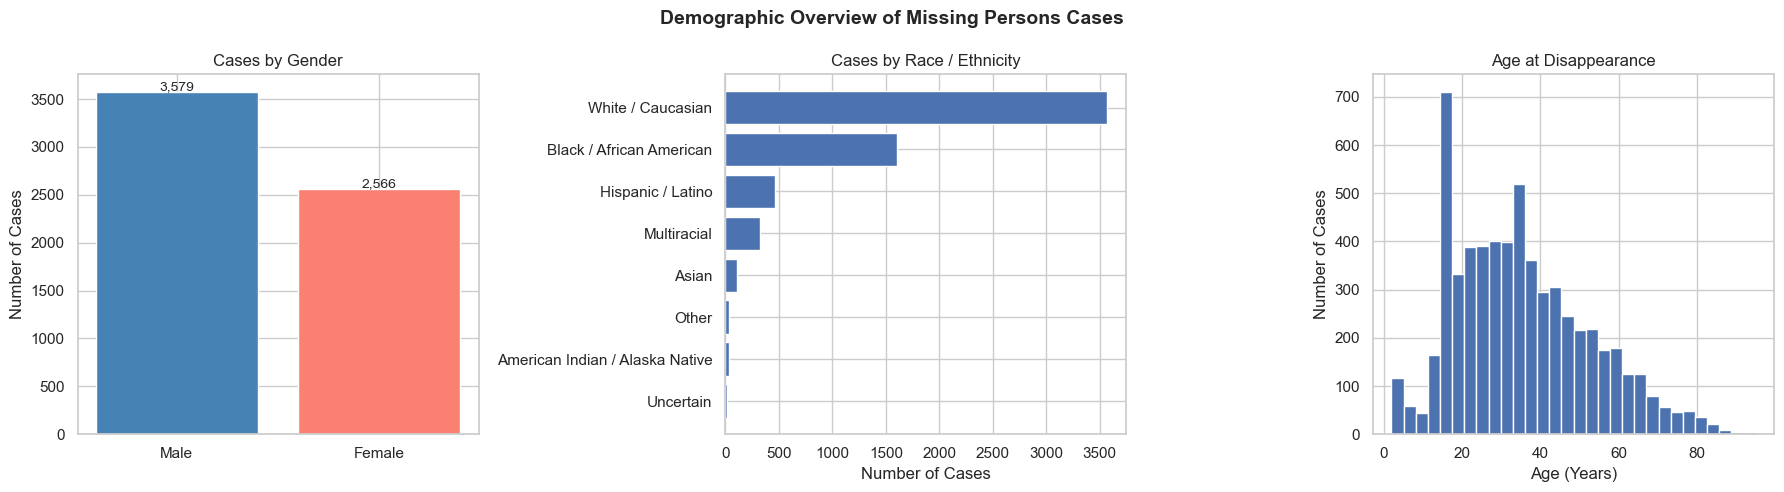

In [33]:
# Plotting demographic data

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Demographic Overview of Missing Persons Cases", fontsize=14, fontweight="bold")

# cound the gender column and graph it
sex_counts = df["Biological Sex"].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Cases by Gender")
axes[0].set_ylabel("Number of Cases")
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=10)

# counting the race column and graphing it
race_counts = df["Race"].value_counts()
axes[1].barh(race_counts.index, race_counts.values)
axes[1].set_title("Cases by Race / Ethnicity")
axes[1].set_xlabel("Number of Cases")
axes[1].invert_yaxis()

# histogram for age. 30 bins looks pretty good.
axes[2].hist(df["Age"].dropna(), bins=30)
axes[2].set_title("Age at Disappearance")
axes[2].set_xlabel("Age (Years)")

# Normalize later
# Use pi chart for proportion breakdown
axes[2].set_ylabel("Number of Cases")

plt.tight_layout()
plt.show()

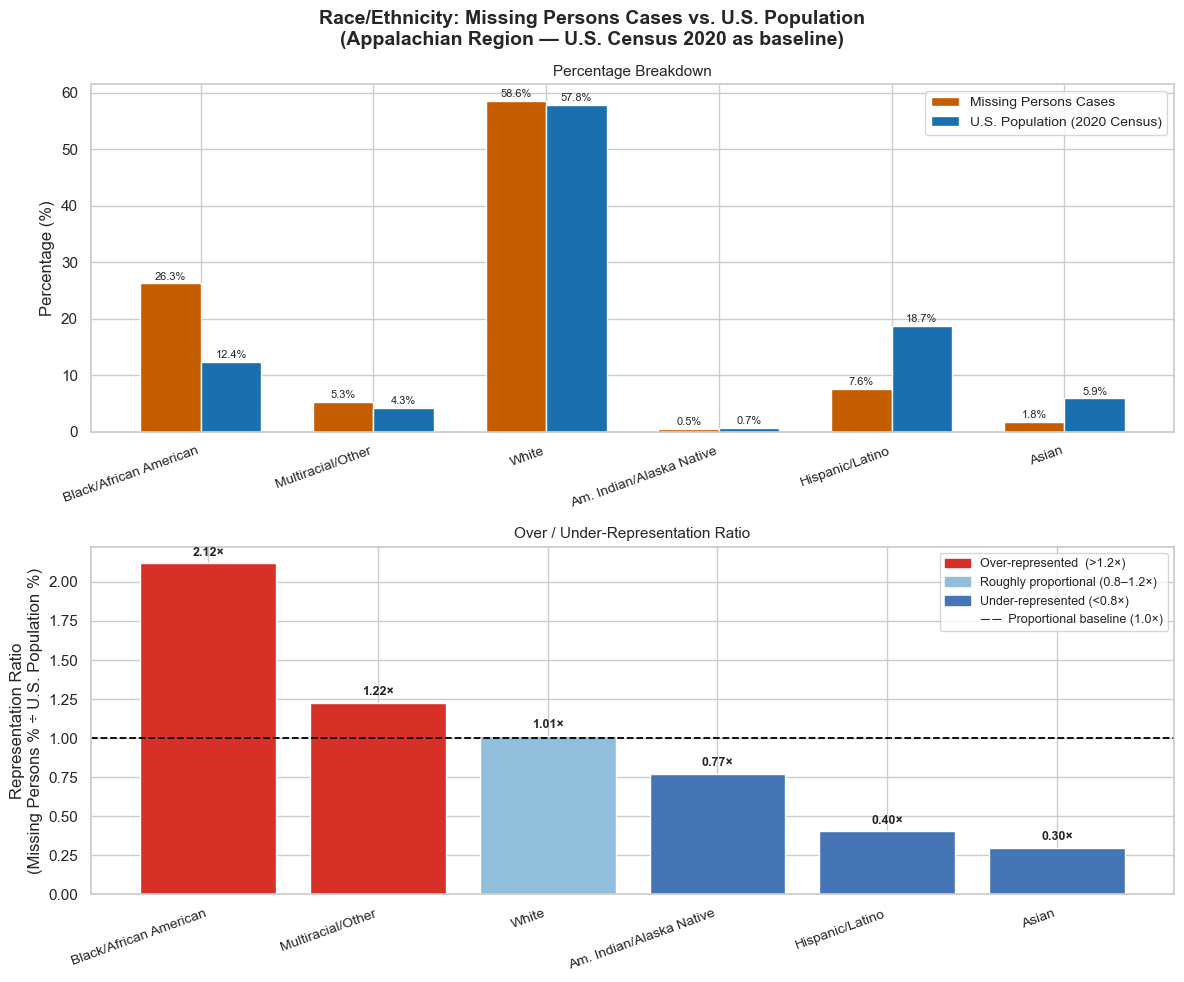

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_mp = pd.read_csv("data/missing_persons_with_coords.csv")

# Map to simplified Census-aligned categories
race_remap = {
    "White / Caucasian":                    "White",
    "Black / African American":             "Black/African American",
    "Hispanic / Latino":                    "Hispanic/Latino",
    "Asian":                                "Asian",
    "American Indian / Alaska Native":      "Am. Indian/Alaska Native",
    "Native Hawaiian / Pacific Islander":   "Native Hawaiian/Pac. Islander",
}
df_mp["Race_clean"] = df_mp["Race / Ethnicity"].apply(
    lambda x: "Multiracial/Other" if "," in str(x)
              else race_remap.get(str(x).strip(), "Unknown/Other")
)

race_counts = df_mp[df_mp["Race_clean"] != "Unknown/Other"]["Race_clean"].value_counts()
race_pct = (race_counts / race_counts.sum() * 100)

# 2020 U.S. Census (non-Hispanic categories where applicable)
us_census = {
    "White":                            57.8,
    "Black/African American":           12.4,
    "Hispanic/Latino":                  18.7,
    "Asian":                             5.9,
    "Am. Indian/Alaska Native":          0.7,
    "Native Hawaiian/Pac. Islander":     0.2,
    "Multiracial/Other":                 4.3,
}

categories = [k for k in us_census if k in race_pct.index]
mp_vals  = np.array([race_pct[c] for c in categories])
us_vals  = np.array([us_census[c] for c in categories])
ratios   = mp_vals / us_vals

# Sort by ratio descending
order = np.argsort(ratios)[::-1]
categories = [categories[i] for i in order]
mp_vals    = mp_vals[order]
us_vals    = us_vals[order]
ratios     = ratios[order]

x     = np.arange(len(categories))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle(
    "Race/Ethnicity: Missing Persons Cases vs. U.S. Population\n"
    "(Appalachian Region — U.S. Census 2020 as baseline)",
    fontsize=14, fontweight="bold"
)

# --- Top: side-by-side percentage bars ---
bars_mp = ax1.bar(x - width/2, mp_vals, width, label="Missing Persons Cases",      color="#c45c00", edgecolor="white")
bars_us = ax1.bar(x + width/2, us_vals, width, label="U.S. Population (2020 Census)", color="#1a6faf", edgecolor="white")
ax1.set_ylabel("Percentage (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=20, ha="right", fontsize=10)
ax1.legend(fontsize=10)
ax1.set_title("Percentage Breakdown", fontsize=11)
for bar in bars_mp:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
for bar in bars_us:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

# --- Bottom: representation ratio ---
bar_colors = ["#d73027" if r > 1.2 else "#4575b4" if r < 0.8 else "#91bfdb" for r in ratios]
bars_r = ax2.bar(x, ratios, color=bar_colors, edgecolor="white")
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1.3, label="Proportional (1.0×)")
ax2.set_ylabel("Representation Ratio\n(Missing Persons % ÷ U.S. Population %)")
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=20, ha="right", fontsize=10)
ax2.set_title("Over / Under-Representation Ratio", fontsize=11)
for bar, ratio in zip(bars_r, ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f"{ratio:.2f}×", ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_patches = [
    mpatches.Patch(color="#d73027", label="Over-represented  (>1.2×)"),
    mpatches.Patch(color="#91bfdb", label="Roughly proportional (0.8–1.2×)"),
    mpatches.Patch(color="#4575b4", label="Under-represented (<0.8×)"),
    mpatches.Patch(color="none",    label="─ ─  Proportional baseline (1.0×)"),
]
ax2.legend(handles=legend_patches, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("race_representation.png", dpi=150, bbox_inches="tight")
plt.show()

# Analysis

In [35]:
# import packages
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "geopandas", "mapclassify"])


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /opt/anaconda3/envs/Lost-In-The-Mountains/bin/python -m pip install --upgrade pip


0

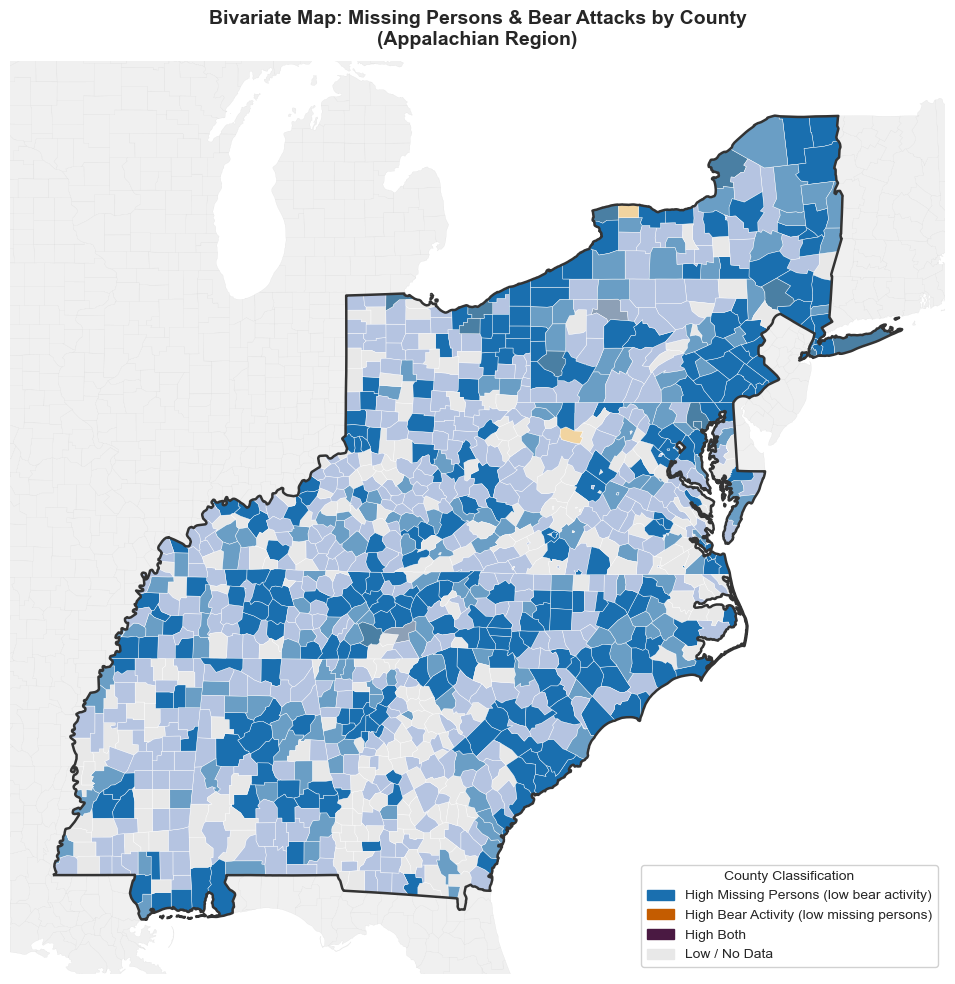

In [36]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load data
df_mp    = pd.read_csv("data/missing_persons_with_coords.csv")
df_bears = pd.read_csv("data/bear_attacks.csv")
df_ref   = pd.read_csv("data/uscounties.csv")

# County-level missing persons count
df_mp["County_clean"] = df_mp["County"].str.strip()
mp_counts = (
    df_mp.groupby(["County_clean", "State"])
    .size()
    .reset_index(name="mp_count")
    .rename(columns={"County_clean": "county_ascii", "State": "state_id"})
)

# Assign bear attacks to counties via nearest county
from scipy.spatial import cKDTree

ref_coords = df_ref[["lat", "lng"]].values
tree = cKDTree(ref_coords)

# Only query rows that have valid coordinates
valid_mask = df_bears[["Latitude", "Longitude"]].notna().all(axis=1)
bear_latlng = df_bears.loc[valid_mask, ["Latitude", "Longitude"]].values
_, idx = tree.query(bear_latlng)

df_bears.loc[valid_mask, "county_ascii"] = df_ref.iloc[idx]["county_ascii"].values
df_bears.loc[valid_mask, "state_id"]     = df_ref.iloc[idx]["state_id"].values
# Rows with no coordinates are excluded from county counts

bear_counts = (
    df_bears.dropna(subset=["county_ascii", "state_id"])
    .groupby(["county_ascii", "state_id"])
    .size()
    .reset_index(name="bear_count")
)

# Download US counties GeoJSON (this is the basis of the map)
import urllib.request, os

geojson_path = "data/us_counties.geojson"
if not os.path.exists(geojson_path):
    url = (
        "https://raw.githubusercontent.com/plotly/datasets/master/"
        "geojson-counties-fips.json"
    )
    urllib.request.urlretrieve(url, geojson_path)

gdf = gpd.read_file(geojson_path)
gdf["county_fips"] = gdf["id"].astype(int)

# Merge counts onto GeoDataFrame
ref_fips = df_ref[["county_ascii", "state_id", "county_fips"]].drop_duplicates()

mp_fips   = mp_counts.merge(ref_fips,  on=["county_ascii", "state_id"], how="left")
bear_fips = bear_counts.merge(ref_fips, on=["county_ascii", "state_id"], how="left")

gdf = gdf.merge(mp_fips[["county_fips", "mp_count"]],    on="county_fips", how="left")
gdf = gdf.merge(bear_fips[["county_fips", "bear_count"]], on="county_fips", how="left")
gdf[["mp_count", "bear_count"]] = gdf[["mp_count", "bear_count"]].fillna(0)

# limit to Appalachian states
appalachian_states = {"AL","GA","KY","MD","MS","NC","NY","OH","PA","SC","TN","VA","WV"}
df_ref["state_fips"] = (df_ref["county_fips"] // 1000).astype(str).str.zfill(2)
state_fips_set = set(
    df_ref[df_ref["state_id"].isin(appalachian_states)]["state_fips"].unique()
)
gdf["state_fips"] = gdf["county_fips"].apply(lambda x: str(x // 1000).zfill(2))
gdf_app = gdf[gdf["state_fips"].isin(state_fips_set)].copy()

# Bivariate classification 3x3 quantile bins
def quantile_bin(series, n=3):
    #Bin non-zero values into n quantile classes; zeros stay at 0
    out = pd.Series(0, index=series.index, dtype=int)
    nonzero = series[series > 0]
    if len(nonzero) == 0:
        return out
    labels = pd.qcut(nonzero, q=n, labels=False, duplicates="drop")
    out[nonzero.index] = labels.values + 1   # 1-indexed so 0 = "none"
    return out.clip(0, n)

gdf_app["mp_class"]   = quantile_bin(gdf_app["mp_count"])
gdf_app["bear_class"] = quantile_bin(gdf_app["bear_count"])

# 8. mp = blue axis, bear = orange axis
bivar_colors = {
    (0, 0): "#e8e8e8",   # no data
    (1, 0): "#b5c4e1",   # low MP only
    (2, 0): "#6a9ec5",   # med MP only
    (3, 0): "#1a6faf",   # high MP only  (blue)
    (0, 1): "#f1d4a0",   # low bear only
    (1, 1): "#c8b89a",   # low MP + low bear
    (2, 1): "#8da0b6",   # med MP + low bear
    (3, 1): "#4a7fa3",   # high MP + low bear
    (0, 2): "#e89c4a",   # med bear only
    (1, 2): "#c48a55",   # low MP + med bear
    (2, 2): "#9a7868",   # med MP + med bear
    (3, 2): "#5b638a",   # high MP + med bear
    (0, 3): "#c45c00",   # high bear only  (orange)
    (1, 3): "#a05030",   # low MP + high bear
    (2, 3): "#7a4560",   # med MP + high bear
    (3, 3): "#4a1942",   # high BOTH       (deep purple)
}

gdf_app["color"] = [
    bivar_colors.get((int(mp), int(b)), "#e8e8e8")
    for mp, b in zip(gdf_app["mp_class"], gdf_app["bear_class"])
]

# plot the map
fig, ax = plt.subplots(figsize=(14, 10))
# US background for context
gdf.plot(color="#f0f0f0", linewidth=0.1, edgecolor="#d0d0d0", ax=ax)
# Appalachian counties with choropleth colors
gdf_app.plot(color=gdf_app["color"], linewidth=0.3, edgecolor="white", ax=ax)
# Thick boundary around the Appalachian region
gdf_app.dissolve().boundary.plot(ax=ax, color="#333333", linewidth=1.8)
# Zoom to Appalachian region
bounds = gdf_app.total_bounds
ax.set_xlim(bounds[0] - 1, bounds[2] + 1)
ax.set_ylim(bounds[1] - 1, bounds[3] + 1)
ax.set_axis_off()
ax.set_title(
    "Bivariate Map: Missing Persons & Bear Attacks by County\n(Appalachian Region)",
    fontsize=14, fontweight="bold", pad=12
)

legend_labels = {
    "High Missing Persons (low bear activity)": "#1a6faf",
    "High Bear Activity (low missing persons)": "#c45c00",
    "High Both":                                "#4a1942",
    "Low / No Data":                            "#e8e8e8",
}
legend_patches = [
    mpatches.Patch(color=c, label=l) for l, c in legend_labels.items()
]
ax.legend(
    handles=legend_patches, loc="lower right",
    framealpha=0.9, fontsize=10, title="County Classification", title_fontsize=10
)

plt.tight_layout()
plt.show()

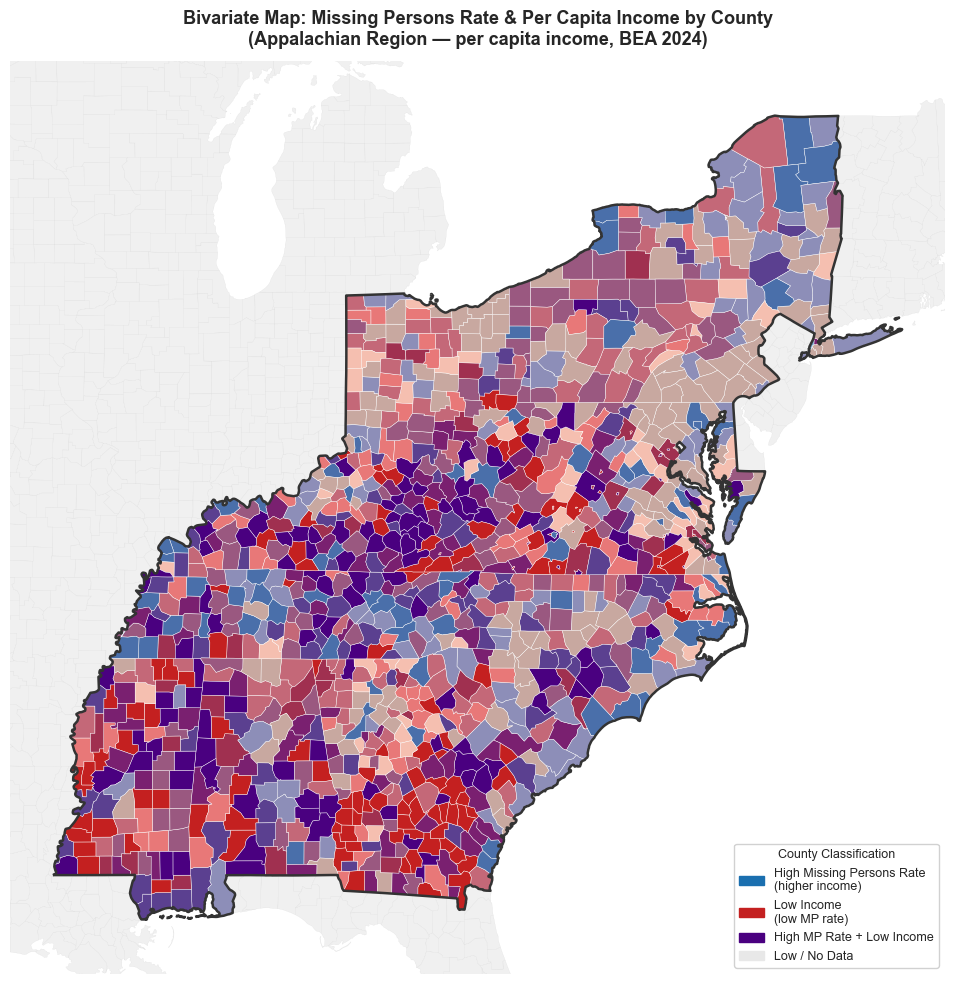

In [37]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load data
df_mp  = pd.read_csv("data/missing_persons_with_coords.csv")
df_ref = pd.read_csv("data/uscounties.csv")
df_eco = pd.read_csv("data/us_county_economic_data.csv", skiprows=3)

# Clean economic data
# GeoFIPS is a 5-digit string; total personal income in thousands of dollars
df_eco["county_fips"] = pd.to_numeric(df_eco["GeoFIPS"].str.strip(), errors="coerce")
df_eco["total_income"] = pd.to_numeric(df_eco["2024"], errors="coerce")
df_eco = df_eco.dropna(subset=["county_fips", "total_income"])
df_eco["county_fips"] = df_eco["county_fips"].astype(int)

# merge county population and icome data
eco_fips = df_eco[["county_fips", "total_income"]].drop_duplicates("county_fips")
ref_pop  = df_ref[["county_fips", "population"]].drop_duplicates("county_fips")
eco_fips = eco_fips.merge(ref_pop, on="county_fips", how="left")
eco_fips["per_capita_income"] = (eco_fips["total_income"] * 1000) / eco_fips["population"]

# scale the missing people
df_mp["County_clean"] = df_mp["County"].str.strip()
mp_counts = (
    df_mp.groupby(["County_clean", "State"])
    .size()
    .reset_index(name="mp_count")
    .rename(columns={"County_clean": "county_ascii", "State": "state_id"})
)
ref_fips = df_ref[["county_ascii", "state_id", "county_fips", "population"]].drop_duplicates()
mp_fips  = mp_counts.merge(ref_fips, on=["county_ascii", "state_id"], how="left")
mp_fips["mp_per_100k"] = (mp_fips["mp_count"] / mp_fips["population"]) * 100_000

# Load county geometries
import urllib.request, os
geojson_path = "data/us_counties.geojson"
if not os.path.exists(geojson_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
        geojson_path
    )
gdf = gpd.read_file(geojson_path)
gdf["county_fips"] = gdf["id"].astype(int)

# get everything onto GeoDataFrame
gdf = gdf.merge(mp_fips[["county_fips",  "mp_per_100k"]],    on="county_fips", how="left")
gdf = gdf.merge(eco_fips[["county_fips", "per_capita_income"]], on="county_fips", how="left")
gdf[["mp_per_100k", "per_capita_income"]] = gdf[["mp_per_100k", "per_capita_income"]].fillna(0)

# filter  to Appalachian states
appalachian_states = {"AL","GA","KY","MD","MS","NC","NY","OH","PA","SC","TN","VA","WV"}
df_ref["state_fips"] = (df_ref["county_fips"] // 1000).astype(str).str.zfill(2)
state_fips_set = set(df_ref[df_ref["state_id"].isin(appalachian_states)]["state_fips"].unique())
gdf["state_fips"] = gdf["county_fips"].apply(lambda x: str(x // 1000).zfill(2))
gdf_app = gdf[gdf["state_fips"].isin(state_fips_set)].copy()

# Bivariate classification (3×3 quantile bins) just like the bears
def quantile_bin(series, n=3):
    out = pd.Series(0, index=series.index, dtype=int)
    nonzero = series[series > 0]
    if len(nonzero) == 0:
        return out
    labels = pd.qcut(nonzero, q=n, labels=False, duplicates="drop")
    out[nonzero.index] = labels.values + 1
    return out.clip(0, n)

gdf_app["mp_class"]  = quantile_bin(gdf_app["mp_per_100k"])
# To make the covariance go in the direction of low income high missing people = positive value
# converting it to max income per capita - county income per capital to invert the data.
income_inverted = gdf_app["per_capita_income"].max() - gdf_app["per_capita_income"]
gdf_app["eco_class"] = quantile_bin(income_inverted)   # high class = low income

# colour palette (probably a better way to do this, I'll figure out how to do a proper heatmap for the final)
bivar_colors = {
    (0, 0): "#e8e8e8",   # no data
    (1, 0): "#b5c4e1",   # low MP, avg income
    (2, 0): "#6a9ec5",   # med MP, avg income
    (3, 0): "#1a6faf",   # high MP, avg income       (blue)
    (0, 1): "#f5bfb0",   # low MP, low income
    (1, 1): "#c8a8a0",   # low MP + low income
    (2, 1): "#8d8eb8",   # med MP + low income
    (3, 1): "#4a6faa",   # high MP + low income
    (0, 2): "#e87878",   # avg MP, lower income
    (1, 2): "#c46878",   # low MP + lower income
    (2, 2): "#9a5880",   # med MP + lower income
    (3, 2): "#5b4090",   # high MP + lower income
    (0, 3): "#c42020",   # low income only            (red)
    (1, 3): "#a03050",   # low MP + low income
    (2, 3): "#7a2070",   # med MP + low income
    (3, 3): "#4a0080",   # high MP + low income       (deep purple)
}

gdf_app["color"] = [
    bivar_colors.get((int(mp), int(eco)), "#e8e8e8")
    for mp, eco in zip(gdf_app["mp_class"], gdf_app["eco_class"])
]

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
# US background for context
gdf.plot(color="#f0f0f0", linewidth=0.1, edgecolor="#d0d0d0", ax=ax)
# Appalachian counties with choropleth colors
gdf_app.plot(color=gdf_app["color"], linewidth=0.3, edgecolor="white", ax=ax)
# Thick boundary around the Appalachian region
gdf_app.dissolve().boundary.plot(ax=ax, color="#333333", linewidth=1.8)
# Zoom to Appalachian region
bounds = gdf_app.total_bounds
ax.set_xlim(bounds[0] - 1, bounds[2] + 1)
ax.set_ylim(bounds[1] - 1, bounds[3] + 1)
ax.set_axis_off()
ax.set_title(
    "Bivariate Map: Missing Persons Rate & Per Capita Income by County\n"
    "(Appalachian Region — per capita income, BEA 2024)",
    fontsize=13, fontweight="bold", pad=12
)

legend_labels = {
    "High Missing Persons Rate\n(higher income)":  "#1a6faf",
    "Low Income\n(low MP rate)":                   "#c42020",
    "High MP Rate + Low Income":                   "#4a0080",
    "Low / No Data":                               "#e8e8e8",
}
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_labels.items()]
ax.legend(handles=patches, loc="lower right", framealpha=0.9,
          fontsize=9, title="County Classification", title_fontsize=9)

plt.tight_layout()
plt.show()

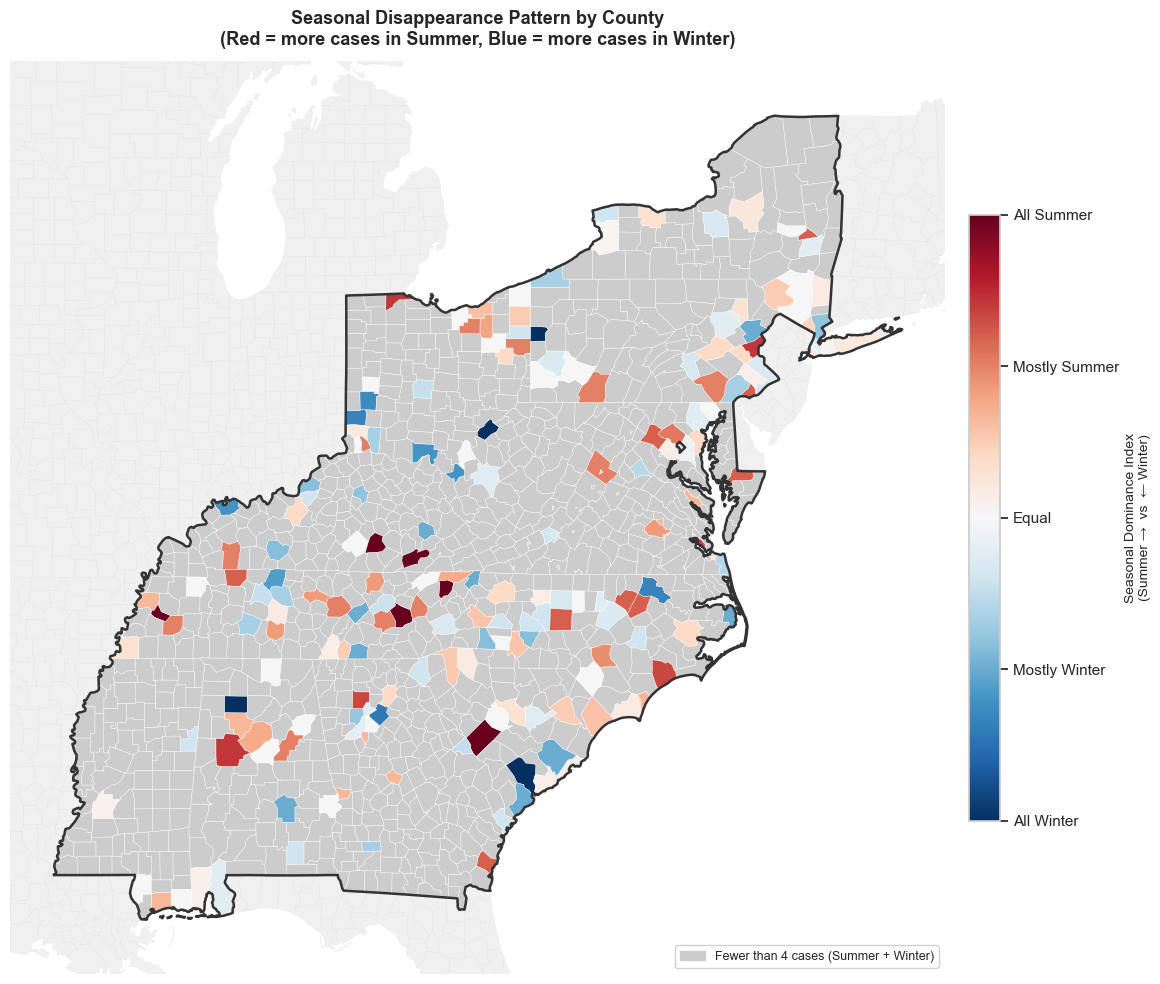

In [38]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Load data
df_mp  = pd.read_csv("data/missing_persons_with_coords.csv")
df_ref = pd.read_csv("data/uscounties.csv")

# Parse date and assign season
df_mp["DLC"] = pd.to_datetime(df_mp["DLC"], errors="coerce")
df_mp["month"] = df_mp["DLC"].dt.month
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring",  4: "Spring",  5: "Spring",
              6: "Summer",  7: "Summer",  8: "Summer",
              9: "Fall",   10: "Fall",   11: "Fall"}
df_mp["season"] = df_mp["month"].map(season_map)

# Count summer and winter cases per county
seasonal = (
    df_mp[df_mp["season"].isin(["Summer", "Winter"])]
    .groupby(["County", "State", "season"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Summer", "Winter"], fill_value=0)
    .reset_index()
    .rename(columns={"County": "county_ascii", "State": "state_id"})
)
seasonal["county_ascii"] = seasonal["county_ascii"].str.strip()

# Seasonal dominance index: +1 = all summer, -1 = all winter
seasonal["total_sw"] = seasonal["Summer"] + seasonal["Winter"]
seasonal["dominance"] = np.where(
    seasonal["total_sw"] >= 4,
    (seasonal["Summer"] - seasonal["Winter"]) / seasonal["total_sw"],
    np.nan
)

# Merge onto FIPS codes
ref_fips = df_ref[["county_ascii", "state_id", "county_fips"]].drop_duplicates()
seasonal_fips = seasonal.merge(ref_fips, on=["county_ascii", "state_id"], how="left")

# Load county geometries
import urllib.request, os
geojson_path = "data/us_counties.geojson"
if not os.path.exists(geojson_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
        geojson_path
    )
gdf = gpd.read_file(geojson_path)
gdf["county_fips"] = gdf["id"].astype(int)

# Merge dominance index onto geodataframe
gdf = gdf.merge(
    seasonal_fips[["county_fips", "dominance"]],
    on="county_fips", how="left"
)

# Filter to Appalachian states
appalachian_states = {"AL","GA","KY","MD","MS","NC","NY","OH","PA","SC","TN","VA","WV"}
df_ref["state_fips"] = (df_ref["county_fips"] // 1000).astype(str).str.zfill(2)
state_fips_set = set(df_ref[df_ref["state_id"].isin(appalachian_states)]["state_fips"].unique())
gdf["state_fips"] = gdf["county_fips"].apply(lambda x: str(x // 1000).zfill(2))
gdf_app = gdf[gdf["state_fips"].isin(state_fips_set)].copy()

# Assign colors from a diverging palette (blue=winter, red=summer, gray=no data)
cmap = plt.cm.RdBu_r

def dominance_to_color(val):
    if pd.isna(val):
        return "#cccccc"
    return mcolors.to_hex(cmap((val + 1) / 2))

gdf_app["color"] = gdf_app["dominance"].apply(dominance_to_color)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
# US background for context
gdf.plot(color="#f0f0f0", linewidth=0.1, edgecolor="#d0d0d0", ax=ax)
# Appalachian counties with choropleth colors
gdf_app.plot(color=gdf_app["color"], linewidth=0.3, edgecolor="white", ax=ax)
# Thick boundary around the Appalachian region
gdf_app.dissolve().boundary.plot(ax=ax, color="#333333", linewidth=1.8)
# Zoom to Appalachian region
bounds = gdf_app.total_bounds
ax.set_xlim(bounds[0] - 1, bounds[2] + 1)
ax.set_ylim(bounds[1] - 1, bounds[3] + 1)
ax.set_axis_off()
ax.set_title(
    "Seasonal Disappearance Pattern by County\n"
    "(Red = more cases in Summer, Blue = more cases in Winter)",
    fontsize=13, fontweight="bold", pad=12
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.025, pad=0.02)
cbar.set_label("Seasonal Dominance Index\n(Summer →  vs  ← Winter)", fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["All Winter", "Mostly Winter", "Equal", "Mostly Summer", "All Summer"])

no_data_patch = mpatches.Patch(color="#cccccc", label="Fewer than 4 cases (Summer + Winter)")
ax.legend(handles=[no_data_patch], loc="lower right", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("seasonal_disappearance_map.png", dpi=150, bbox_inches="tight")
plt.show()

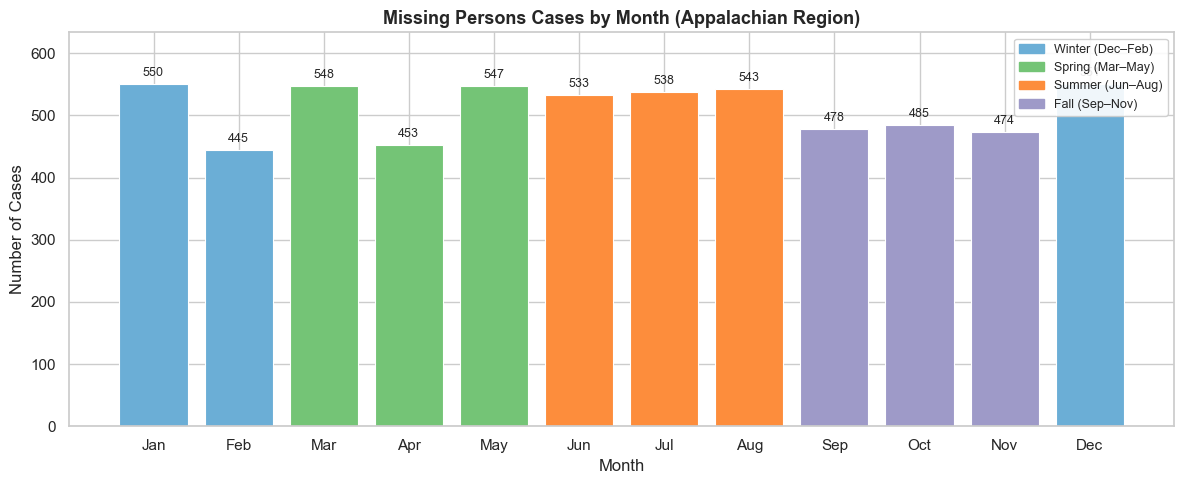

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_mp = pd.read_csv("data/missing_persons_with_coords.csv")
df_mp["DLC"] = pd.to_datetime(df_mp["DLC"], errors="coerce")
df_mp["month"] = df_mp["DLC"].dt.month

month_counts = df_mp["month"].value_counts().sort_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

season_colors = {
    1: "#6baed6", 2: "#6baed6", 3: "#74c476",
    4: "#74c476", 5: "#74c476", 6: "#fd8d3c",
    7: "#fd8d3c", 8: "#fd8d3c", 9: "#9e9ac8",
    10: "#9e9ac8", 11: "#9e9ac8", 12: "#6baed6"
}
bar_colors = [season_colors[m] for m in month_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(month_labels, month_counts.values, color=bar_colors, edgecolor="white", linewidth=0.8)

ax.set_title("Missing Persons Cases by Month (Appalachian Region)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Cases")
ax.set_ylim(0, month_counts.max() * 1.15)

for bar, val in zip(bars, month_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(val), ha="center", va="bottom", fontsize=9)

legend_patches = [
    mpatches.Patch(color="#6baed6", label="Winter (Dec–Feb)"),
    mpatches.Patch(color="#74c476", label="Spring (Mar–May)"),
    mpatches.Patch(color="#fd8d3c", label="Summer (Jun–Aug)"),
    mpatches.Patch(color="#9e9ac8", label="Fall (Sep–Nov)"),
]
ax.legend(handles=legend_patches, loc="upper right", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

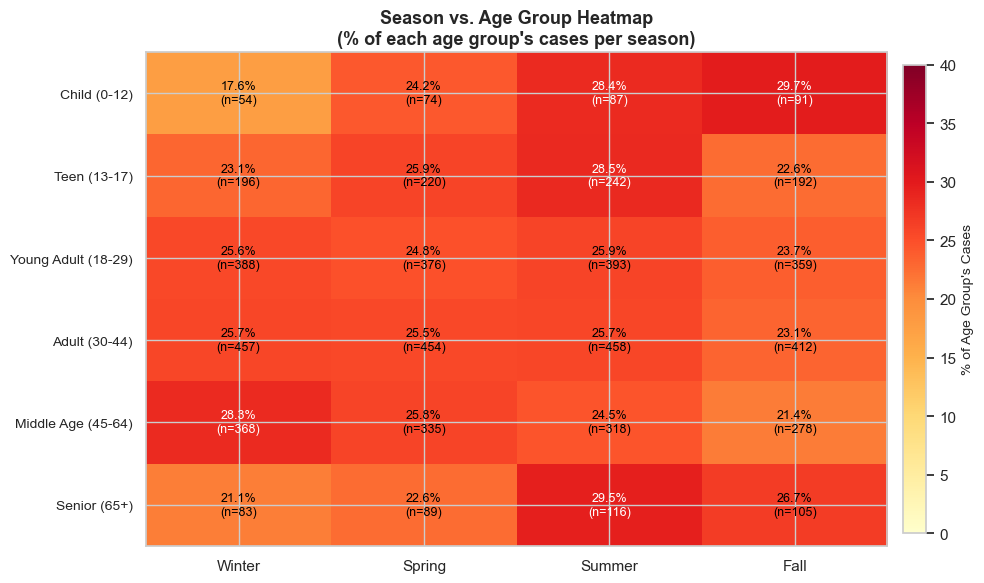

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_mp = pd.read_csv("data/missing_persons_with_coords.csv")
df_mp["DLC"] = pd.to_datetime(df_mp["DLC"], errors="coerce")
df_mp["month"] = df_mp["DLC"].dt.month
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring",  4: "Spring",  5: "Spring",
              6: "Summer",  7: "Summer",  8: "Summer",
              9: "Fall",   10: "Fall",   11: "Fall"}
df_mp["season"] = df_mp["month"].map(season_map)

# Parse age from "17 Years" format
df_mp["age_val"] = pd.to_numeric(
    df_mp["Missing Age"].str.extract(r"(\d+)")[0], errors="coerce"
)

# Age buckets
bins   = [0, 12, 17, 29, 44, 64, 120]
labels = ["Child (0-12)", "Teen (13-17)", "Young Adult (18-29)",
          "Adult (30-44)", "Middle Age (45-64)", "Senior (65+)"]
df_mp["age_group"] = pd.cut(df_mp["age_val"], bins=bins, labels=labels, right=True)

# Pivot: rows = age group, columns = season (ordered)
season_order = ["Winter", "Spring", "Summer", "Fall"]
pivot = (
    df_mp.dropna(subset=["age_group", "season"])
    .groupby(["age_group", "season"])
    .size()
    .unstack("season")
    .reindex(columns=season_order)
)

# Normalize each row to show proportions within each age group
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot_norm.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=40)

ax.set_xticks(range(len(season_order)))
ax.set_xticklabels(season_order, fontsize=11)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title("Season vs. Age Group Heatmap\n(% of each age group's cases per season)",
             fontsize=13, fontweight="bold")

for r in range(pivot_norm.shape[0]):
    for c in range(pivot_norm.shape[1]):
        val = pivot_norm.iloc[r, c]
        raw = pivot.iloc[r, c]
        text_color = "white" if val > 28 else "black"
        ax.text(c, r, f"{val:.1f}%\n(n={int(raw)})",
                ha="center", va="center", fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("% of Age Group's Cases", fontsize=10)

plt.tight_layout()
plt.show()

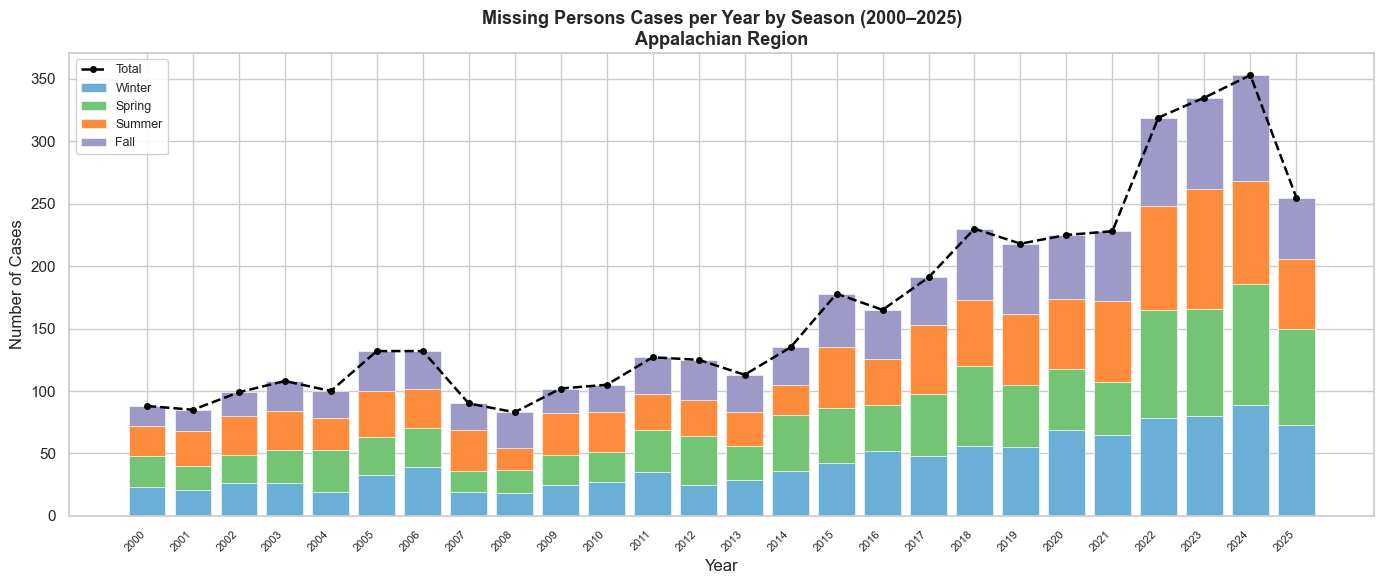

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df_mp = pd.read_csv("data/missing_persons_with_coords.csv")
df_mp["DLC"] = pd.to_datetime(df_mp["DLC"], errors="coerce")
df_mp["year"]  = df_mp["DLC"].dt.year
df_mp["month"] = df_mp["DLC"].dt.month
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring",  4: "Spring",  5: "Spring",
              6: "Summer",  7: "Summer",  8: "Summer",
              9: "Fall",   10: "Fall",   11: "Fall"}
df_mp["season"] = df_mp["month"].map(season_map)

# making the year cutoff 2000 because there is so little data each year before that.
df_trend = df_mp[(df_mp["year"] >= 2000) & (df_mp["year"] <= 2025)].copy()

season_order  = ["Winter", "Spring", "Summer", "Fall"]
season_colors = {"Winter": "#6baed6", "Spring": "#74c476",
                 "Summer": "#fd8d3c", "Fall":   "#9e9ac8"}

yearly = (
    df_trend.groupby(["year", "season"])
    .size()
    .unstack("season")
    .reindex(columns=season_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 6))

bottom = pd.Series(0, index=yearly.index)
for season in season_order:
    ax.bar(yearly.index, yearly[season], bottom=bottom,
           color=season_colors[season], label=season, edgecolor="white", linewidth=0.4)
    bottom = bottom + yearly[season]

# Total line overlay
totals = yearly.sum(axis=1)
ax.plot(yearly.index, totals, color="black", linewidth=1.8,
        linestyle="--", marker="o", markersize=4, label="Total", zorder=5)

# Graph formatting
ax.set_title("Missing Persons Cases per Year by Season (2000–2025)\nAppalachian Region",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Cases")
ax.set_xticks(yearly.index)
ax.set_xticklabels(yearly.index, rotation=45, ha="right", fontsize=8)
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

## Results



....


## Ethical Considerations


The names column has been dropped as stated in the project proposal to protect identities and make our project more ethical.

Specific counties have been highlighted as "more or less likely to have missing persons cases", however it would be a mistake to draw conclusions about the safety of these counties based on this analysis, as there is not a granular enough level of location information available on the NAMUS database to determine if this is the location of police department where case was filed, or if this is the geographic region that the person was last seen.

## Project Summary


....

